Nick and David

In [ ]:
#https://www.kaggle.com/datasets/piyushgoyal443/red-wine-dataset

In [ ]:
#we imported all necessary libraries for this algorithm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

In [ ]:
#imported the datasets that contains wine quality
from google.colab import files
uploaded =files.upload()
df=pd.read_csv("wineQualityReds.csv")
df

Saving wineQualityReds.csv to wineQualityReds.csv


,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,1,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,2,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,3,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,4,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,5,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,1595,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,1596,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,1597,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,1598,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
#Checking if the datasets have a null values
df.isnull().sum()

,0
Unnamed: 0,0
fixed.acidity,0
volatile.acidity,0
citric.acid,0
residual.sugar,0
chlorides,0
free.sulfur.dioxide,0
total.sulfur.dioxide,0
density,0
pH,0


In [ ]:
#We dropped a column that was irellevent to the algorithm
df.drop(columns=['Unnamed: 0' ], inplace=True)
df.head()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
#using the columns as refrence for future code
df.columns

Index(['fixed.acidity', 'volatile.acidity', 'citric.acid', 'residual.sugar',
       'chlorides', 'free.sulfur.dioxide', 'total.sulfur.dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
print("=" * 60)
print("Multi-Class Classification Strategy Comparison")
print("=" * 60)

Multi-Class Classification Strategy Comparison


In [ ]:
#setting a variables towards the relevent features
#setting the target variable towards the type of quality
x=df[['fixed.acidity', 'volatile.acidity', 'citric.acid', 'residual.sugar', 'chlorides', 'free.sulfur.dioxide', 'total.sulfur.dioxide', 'density', 'pH', 'sulphates', 'alcohol']]
y=df['quality']

In [ ]:
#splitting the data set into testing and training sets
#30% goes to the testing set and the rest goes into training
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [ ]:
print("\n" + "=" * 60)
print("STRATEGY 1: Standard SVM (Default)")
print("=" * 60)


STRATEGY 1: Standard SVM (Default)


In [ ]:
#This will give you the amount of time it takes to train the dataset
#we will first start using this training set for a standard svm
start_time = time.time()
model_standard = SVC(kernel = 'rbf', gamma='scale', C=1.0)
model_standard.fit(x_train, y_train)
train_time_standard = time.time() - start_time
#this will present an accuracy of the dataset based on the target variable
#it will print the accuracy
y_pred_standard = model_standard.predict(x_test)
accuracy_standard = accuracy_score(y_test, y_pred_standard)
print(f"\nResults:")
print(f" Training time: {train_time_standard:.4f} seconds")
print(f" Accuracy: {accuracy_standard * 100:.2f}%")


Results:
 Training time: 0.0893 seconds
 Accuracy: 50.42%


In [ ]:
print("\n" + "=" *70)
print("Strategy 2: One-VS-Rest (OvA)")
print("=" * 70)


Strategy 2: One-VS-Rest (OvA)


In [ ]:
#This is the same thing but it will train the set for a OvA
start_time = time.time()
model_ovr = OneVsRestClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
model_ovr.fit(x_train, y_train)
train_time_ovr = time.time() - start_time
#printing the same accuracy
#Prints out the number of classifiers trained
y_pred_ovr = model_ovr.predict(x_test)
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)

print(f"\nResults:")
print(f" Training time: {train_time_ovr:.4f} seconds")
print(f" Accuracy: {accuracy_ovr * 100:.2f}%")
print(f" Number of classifiers trained: {len(model_ovr.estimators_)}")


Results:
 Training time: 0.2084 seconds
 Accuracy: 50.21%
 Number of classifiers trained: 6


In [ ]:
print("\n" + "=" * 70)
print("STRATEGY 3: One-vs-One (OvO)")
print("=" * 70)


STRATEGY 3: One-vs-One (OvO)


In [ ]:
#This is the same thing but only for OvO
start_time = time.time()
model_ovo = OneVsOneClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
model_ovo.fit(x_train, y_train)
train_time_ovo = time.time() - start_time
#printing out the same accuracy for the training set
#gives you the number of classifiers trained
y_pred_ovo = model_ovo.predict(x_test)
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)
print(f"\nResults:")
print(f" Training time: {train_time_ovo:.4f} seconds")
print(f" Accuracy: {accuracy_ovo * 100:.2f}%")
print(f" Number of classifiers trained: {len(model_ovo.estimators_)}")


Results:
 Training time: 0.1074 seconds
 Accuracy: 50.21%
 Number of classifiers trained: 15


In [ ]:
print("\n" + "=" * 70)
print("FINAL COMPARISON SUMMARY")
print("=" * 70)



FINAL COMPARISON SUMMARY


In [ ]:
#showing all accuracy for all strategies with amount of time and the number of classifiers
#comparing all strategies
print(f"\n{'Strategy':<20} {'Accuracy':<12} {'Training Time':<15} {'# Classifiers'}")
print("-" * 70)
print(f"{'Standard SVM':<20} {accuracy_standard*100:>6.2f}%     {train_time_standard:>8.4f}s      N/A (built-in)")
print(f"{'One-vs-Rest (OvA)':<20} {accuracy_ovr*100:>6.2f}%     {train_time_ovr:>8.4f}s      {len(model_ovr.estimators_)}")
print(f"{'One-vs-One (OvO)':<20} {accuracy_ovo*100:>6.2f}%     {train_time_ovo:>8.4f}s      {len(model_ovo.estimators_)}")


Strategy             Accuracy     Training Time   # Classifiers
----------------------------------------------------------------------
Standard SVM          50.42%       0.0893s      N/A (built-in)
One-vs-Rest (OvA)     50.21%       0.2084s      6
One-vs-One (OvO)      50.21%       0.1074s      15


In [ ]:
#based on all the strategies we have made and trained
#It will print out the best strategy with the best accuracy
accuracies = {
    'Standard SVM': accuracy_standard,
    'One-vs-Rest (OvA)': accuracy_ovr,
    'One-vs-One (OvO)': accuracy_ovo
}
best_strategy = max(accuracies, key=accuracies.get)
print(f"\nBest Accuracy: {best_strategy}")


Best Accuracy: Standard SVM


In [ ]:
#printing out the classification report based on the dataset
#This is only based on the OvO strategy with each column
print("\n" + "=" * 70)
print("DETAILED CLASSIFICATION REPORT (One-vs-One Strategy)")
print("=" * 70)
print(classification_report(y_test, y_pred_ovo))



DETAILED CLASSIFICATION REPORT (One-vs-One Strategy)
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        17
           5       0.59      0.50      0.54       195
           6       0.45      0.71      0.55       200
           7       1.00      0.02      0.03        61
           8       0.00      0.00      0.00         6

    accuracy                           0.50       480
   macro avg       0.34      0.20      0.19       480
weighted avg       0.56      0.50      0.46       480


Generating visualization...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


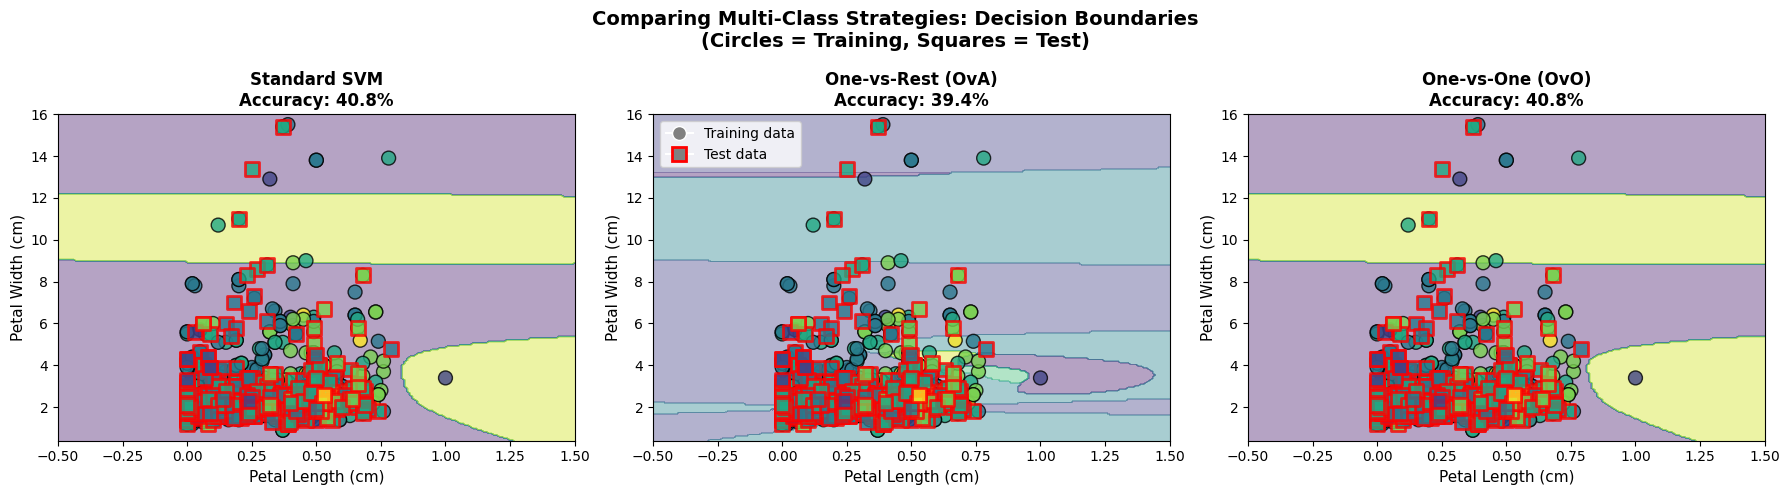

In [ ]:
#we will train the sets for a 2d plane
x_2d = x.iloc[:, 2:4].values
x_train_2d, x_test_2d, y_train_2d, y_test_2d = train_test_split(
    x_2d, y, test_size=0.3, random_state=42
)
# we will use all the trained strategies into their own seperate plot
models_2d = {
    'Standard SVM': SVC(kernel='rbf', gamma='scale', C=1.0),
    'One-vs-Rest (OvA)': OneVsRestClassifier(SVC(kernel='rbf', gamma='scale', C=1.0)),
    'One-vs-One (OvO)': OneVsOneClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
}
#This will create three subplots and create the min and max boundaries
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_min, x_max = x_2d[:, 0].min() - 0.5, x_2d[:, 0].max() + 0.5
y_min, y_max = x_2d[:, 1].min() - 0.5, x_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
#fitting all trained sets and fiting into the models
for idx, (name, model) in enumerate(models_2d.items()):
    model.fit(x_train_2d, y_train_2d)
#we will use the trained sets to predict the datasets using the algorithm
    y_pred_2d = model.predict(x_test_2d)
    acc_2d = accuracy_score(y_test_2d, y_pred_2d)
#making the boundaries of the plots
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
#setting the size of the points and creating a scatter plot
    scatter = axes[idx].scatter(x_train_2d[:, 0], x_train_2d[:, 1],
                               c=y_train_2d, edgecolors='k',
                               cmap='viridis', s=100, alpha=0.8)

    axes[idx].scatter(x_test_2d[:, 0], x_test_2d[:, 1],
                     c=y_test_2d, edgecolors='red', linewidths=2,
                     cmap='viridis', s=100, alpha=0.8, marker='s')
#making the labels for the plot and title
    axes[idx].set_xlabel('Petal Length (cm)', fontsize=11)
    axes[idx].set_ylabel('Petal Width (cm)', fontsize=11)
    axes[idx].set_title(f'{name}\nAccuracy: {acc_2d*100:.1f}%',
                       fontsize=12, fontweight='bold')
#importing another library
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=10, label='Training data'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
           markeredgecolor='red', markeredgewidth=2, markersize=10, label='Test data')
]
axes[1].legend(handles=legend_elements, loc='upper left')

plt.suptitle('Comparing Multi-Class Strategies: Decision Boundaries\n(Circles = Training, Squares = Test)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

My partner and I used a dataset the used wine stats to determine the wine quality. We used this dataset to show the comparison between three different strategies, which are the standard svm, One vs Rest, and One vs One. These strategies are related to the support vectors machine algorithm. We wanted to predict the different wine quality based on the different features each wine has. As you can see on the graphs, there are many points spread out through the graphs. There are two sets which is the testing and training sets. We can determine the quality by distance of the points and the lines that you see on the graph. The farther they are away from the lines the better chance we can determine the quality. The standard svm is the regular strategy and the one to one method which is a multi-group approach and it grabs two classes and trains it. It does this for multiple classes and votes on the best class. One versus All trains one classifer per class. The classifier is trained on the entire dataset but the target class is treated as one class. The datasets we used did not have a high accuracy as you can see on each graph so that is why the graph may seem everywhere but this is an example using a large dataset. This algorithm is better for small to medium datasets.